In [1]:
# This python notebook will create a CNN for predicting steering angles from a central dashcam in normal lighting conditions, then it will
# test the model under varying lighting conditions

# Then the notebook will create a CNN trained on varying lighting conditions and test the model under the same varying conditions

In [2]:
#Importing the required libraries
import os
print("OS Imported")
import numpy as np
print("Numpy Imported")
import pandas as pd
print("Pandas Imported")
import cv2
print("cv2 Imported")
import matplotlib.pyplot as plt
print("Matplotlib Imported")
from sklearn.model_selection import train_test_split
print("Sklearn Model Selection Imported")
from sklearn.metrics import mean_squared_error, r2_score
print("Sklearn metrics Imported")
from tensorflow.keras.models import Sequential
print("keras models Imported")
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Input
print("keras layers Imported")
from tensorflow.keras.optimizers import Adam
print("keras optimizers Imported")
from tensorflow.keras.callbacks import EarlyStopping
print("keras callbacks Imported")
import random
print("random Imported")
print("All libraries are successfully loaded")

OS Imported
Numpy Imported
Pandas Imported
cv2 Imported
Matplotlib Imported
Sklearn Model Selection Imported
Sklearn metrics Imported
keras models Imported
keras layers Imported
keras optimizers Imported
keras callbacks Imported
random Imported
All libraries are successfully loaded


In [3]:
# Currently the images that I am using are from https://www.kaggle.com/datasets/andy8744/udacity-self-driving-car-behavioural-cloning, I 
# used the road and not the jungle dataset.

# One problem with this approach is that the images were for windows files and I am using a macbook, hence i needed to re-write the image
# paths

# My file paths
datasetCsvPath = "/Users/redsparrow/Desktop/Coding/LumierePaper/driving_log.csv"
imgFolder = "/Users/redsparrow/Desktop/Coding/LumierePaper/IMG/"

# loading the dataset with custom column names
column = ['center', 'left', 'right', 'steeringAngle', 'throttle', 'reverse', 'speed']
df = pd.read_csv(datasetCsvPath, header=None, names=column)

def fixPath(x):
    x = x.replace("\\", "/")
    return os.path.join(imgFolder, os.path.basename(x))

df['center'] = df['center'].apply(fixPath)
df['left']   = df['left'].apply(fixPath)
df['right']  = df['right'].apply(fixPath)

In [16]:
# Defining the functions that I will use throughout this project

# loads the image useing opencv
def loadImage(path):
    img = cv2.imread(path)
    if img is None:
        print("FAILED:", path)
        return np.zeros((66,200,3))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (200, 66))
    img = img / 255.0
    return img

# This augment function simply reverses the angle and flips the image
def augmentImage(img, angle):
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
        angle = -angle
    return img, angle

# This augment function reverses the angle, flips the image and changes the brightness
def augmentImageWithBrightness(img,angle,value):
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
        angle = -angle
    if value >= 1:
        #bright lighting
        if random.random() > 0.5:
            img = brightenImage(img,value)
        
    elif value <= 1:
        # Dark lighting
        if random.random() > 0.5:
            img = darkenImage(img,value)
        
    return img, angle

# This augment function reverses the angle, flips the image and changes the brightness
def augmentImageWithBrightnessForTraining(img,angle):
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
        angle = -angle
    choice = random.choice(['normal', 'bright', 'dark'])
    if choice == 'bright':
        img = brightenImage(img,1.5)
        
    elif choice == 'dark':
        img = darkenImage(img,0.5)
        
    return img, angle
    
# Generator batches images together
def generator(df, batch_size=32):
    while True:
        batchImages = []
        batchAngles = []
        df = df.sample(frac=1)  # shuffle
        for _, row in df.iterrows():
            # Choose randomly center/left/right
            choice = random.choice(['center', 'left', 'right'])
            angle = row['steeringAngle']
            correction = 0.25
            if choice == 'left':
                angle += correction
            elif choice == 'right':
                angle -= correction
            img = loadImage(row[choice])
            img, angle = augmentImage(img, angle)
            batchImages.append(img)
            batchAngles.append(angle)
            if len(batchImages) == batch_size:
                yield np.array(batchImages), np.array(batchAngles)
                batchImages, batchAngles = [], []

def generatorForBrightness(df,value,batch_size=32):
    while True:
        batchImages = []
        batchAngles = []
        df = df.sample(frac=1)  # shuffle
        for _, row in df.iterrows():
            # Choose randomly center/left/right
            choice = random.choice(['center', 'left', 'right'])
            angle = row['steeringAngle']
            correction = 0.25
            if choice == 'left':
                angle += correction
            elif choice == 'right':
                angle -= correction
            img = loadImage(row[choice])
            img, angle = augmentImageWithBrightness(img, angle, value)
            batchImages.append(img)
            batchAngles.append(angle)
            if len(batchImages) == batch_size:
                yield np.array(batchImages), np.array(batchAngles)
                batchImages, batchAngles = [], []

def trainingGeneratorForBrightness(df,batch_size=32):
    while True:
        batchImages = []
        batchAngles = []
        df = df.sample(frac=1)  # shuffle
        for _, row in df.iterrows():
            # Choose randomly center/left/right
            choice = random.choice(['center', 'left', 'right'])
            angle = row['steeringAngle']
            correction = 0.25
            if choice == 'left':
                angle += correction
            elif choice == 'right':
                angle -= correction
            img = loadImage(row[choice])
            img, angle = augmentImageWithBrightnessForTraining(img, angle)
            batchImages.append(img)
            batchAngles.append(angle)
            if len(batchImages) == batch_size:
                yield np.array(batchImages), np.array(batchAngles)
                batchImages, batchAngles = [], []

def brightenImage(img, factor=1.5):
    # remember original type/range
    type1 = np.issubdtype(img.dtype, np.floating)
    
    if type1:
        imgB = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    else:
        imgB = img.copy()

    # convert to HSV, apply factor on V (value), convert back
    hsv = cv2.cvtColor(imgB, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 2] = np.clip(hsv[..., 2] * factor, 0, 255)
    bright = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    # return in same dtype/range as input
    if type1:
        return bright.astype(np.float32) / 255.0
    else:
        return bright

def darkenImage(img, factor=0.5):
    # remember original type/range
    type1 = np.issubdtype(img.dtype, np.floating)

    # convert to unit8 RGB for safe OpenCV color conversions
    if type1:
        imgD = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    else:
        imgD = img.copy()

    hsv = cv2.cvtColor(imgD, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 2] = np.clip(hsv[..., 2] * factor, 0, 255)
    dark = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    # return in same dtype/range as input
    if type1:
        return dark.astype(np.float32) / 255.0
    else:
        return dark

#number of departures - used for accuracy analysis
def laneDepart(yValReal,yPred):
    departures = 0
    for i in range(len(yValReal)):
        # Assumption 1 - if the predicted angle and actual angle are of different signs (predicts left when it has to turn right 
        # or vice versa) a lane departure has occured
        # multiply the numbers to check if the product is negative
        if(yValReal[i]*yPred[i]<0):
            departures += 1
        # Assumption 2 - if the predicted angle and actual angle have a difference greater than or equal to 0.1 (rad) 
        # then a lane departure has happened
        elif(abs(yValReal[i]-yPred[i])>=0.1):
            departures += 1
    # return the total number of departures found
    return departures

def dispTurnError(yValReal,yPred):
    departed = laneDepart(yValReal,yPred)
    # total turns
    print(f"The total amount of turns sampled in this dataset is: {len(yValReal)}")
    # wrong turns leading to lane departure
    print(f"The amount of lane departures caused by this model is: {departed}")
    # turn error rate % rounded to 2 decimal points
    print(f"Turn error rate: {round(departed*100/len(yValReal), 2)}%")

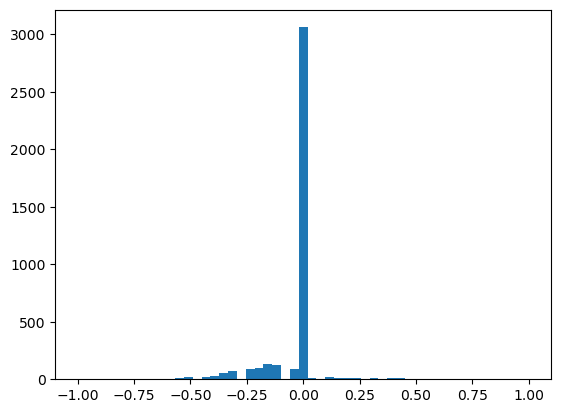

In [5]:
# Visualising the dataset's contained angles
plt.hist(df['steeringAngle'],bins = 51)
plt.show()

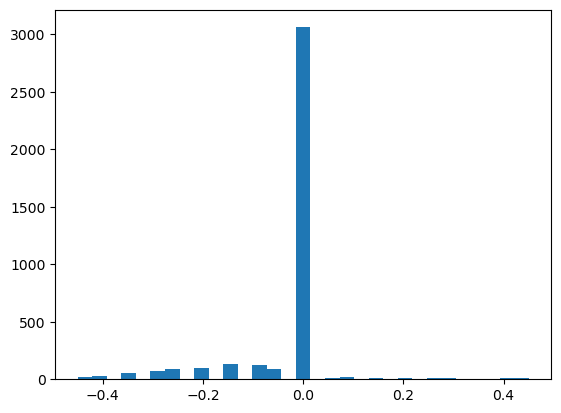

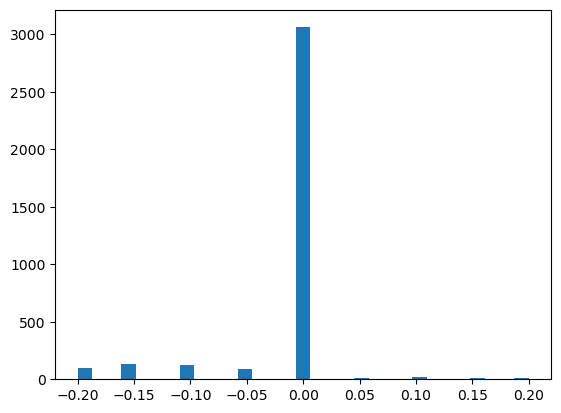

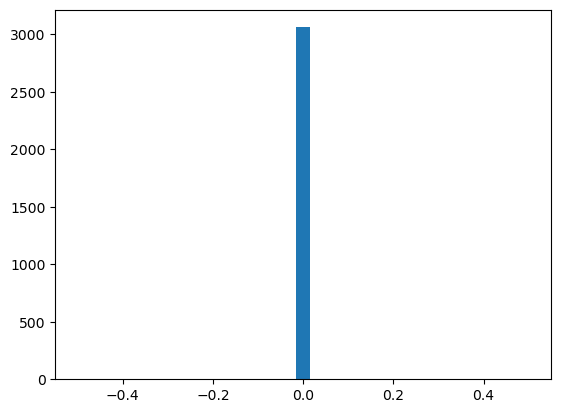

In [6]:
# Narrowing the dataset to find the straight angles threshold
testDf = df[df['steeringAngle'].abs() < 0.5]
plt.hist(testDf['steeringAngle'],bins = 31)
plt.show() # too many different angles other than 0.0
testDf = df[df['steeringAngle'].abs() < 0.25]
plt.hist(testDf['steeringAngle'],bins = 31)
plt.show() # better but still has other angles
testDf = df[df['steeringAngle'].abs() < 0.05]
plt.hist(testDf['steeringAngle'],bins = 31)
plt.show() # contains only 0.0 angles, will be used for balancing

In [7]:
# we will now train a base model on the ENTIRE dataset
# this will be our base model

# Splitting the dataset and using Nvidia's model architecture
# Split dataset
trainDf, valDf = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

In [8]:
# Model
ControlledAnglePredictor = Sequential([
    Input(shape=(66,200,3)),
    Conv2D(24, (5,5), strides=(2,2), activation='relu'),
    Conv2D(36, (5,5), strides=(2,2), activation='relu'),
    Conv2D(48, (5,5), strides=(2,2), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1)
])
ControlledAnglePredictor.compile(
    optimizer='adam', 
    loss='mean_squared_error',
    metrics=['accuracy']
)
ControlledAnglePredictor.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Training
batchSize = 32
stepsPerEpoch = len(trainDf) // batchSize
validationSteps = len(valDf) // batchSize

earlyStop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history = ControlledAnglePredictor.fit(
    generator(trainDf, batchSize),
    steps_per_epoch=stepsPerEpoch,
    validation_data=generator(valDf, batchSize),
    validation_steps=validationSteps,
    epochs=30,
    callbacks=[earlyStop]
)

ControlledAnglePredictor.save("ControlledAnglePredictor.keras")

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.2787 - loss: 0.0423 - val_accuracy: 0.2656 - val_loss: 0.0225
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.2675 - loss: 0.0193 - val_accuracy: 0.2422 - val_loss: 0.0171
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2580 - loss: 0.0169 - val_accuracy: 0.2656 - val_loss: 0.0171
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2628 - loss: 0.0161 - val_accuracy: 0.2500 - val_loss: 0.0175
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.2519 - loss: 0.0157 - val_accuracy: 0.2526 - val_loss: 0.0159
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.2828 - loss: 0.0150 - val_accuracy: 0.2279 - val_loss: 0.0145
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.2736 - loss: 0.0145 - val_accuracy: 0.2708 - val_loss: 0.0135
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.2784 - loss: 0.0140 - val_accuracy: 0.2422 - v

MSE: 0.008670995848944724
R² : 0.8294319979978766


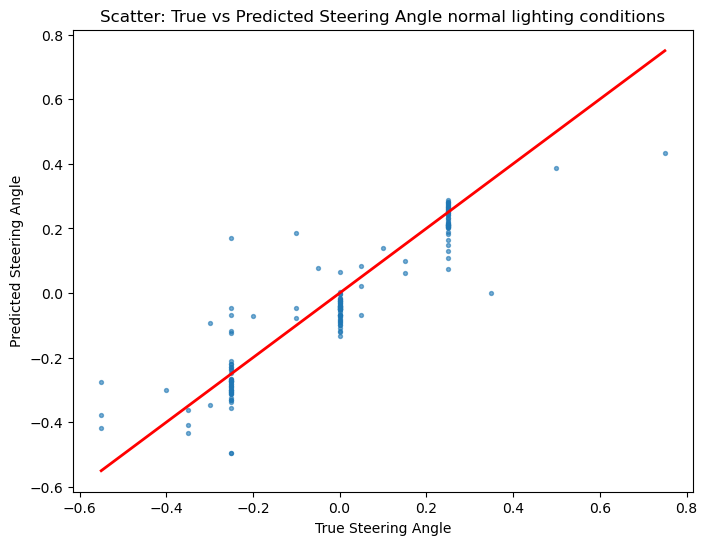

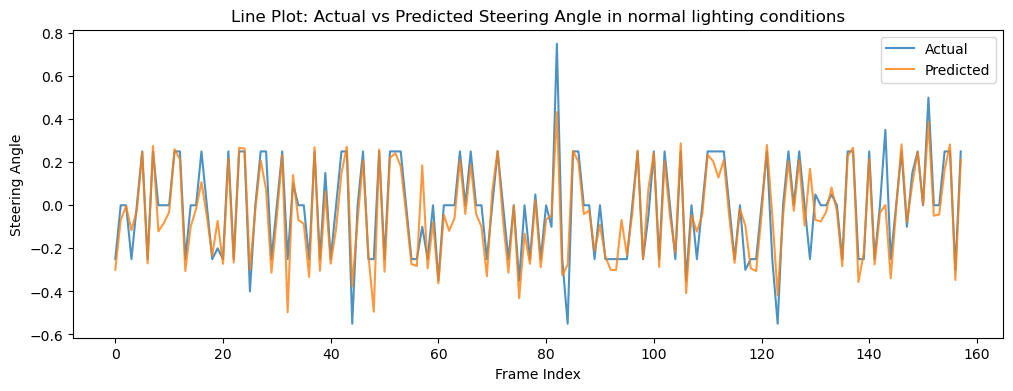

The total amount of turns sampled in this dataset is: 158
The amount of lane departures caused by this model is: 27
Turn error rate: 17.09%


In [10]:
# Testing the model
# Making predictions

#Testing dataset
xFullList = []
yFullList = [] # Start with an empty list
correction = 0.25

for i in range(len(valDf)):
    # Get the current row data
    row = valDf.iloc[i]
    choice = random.choice(['center', 'left', 'right'])
    xFullList.append(row[choice])
    # Calculate corrected angle
    angle = row['steeringAngle']
    if choice == 'left':
        angle += correction
    elif choice == 'right':
        angle -= correction
        
    yFullList.append(angle)
# Convert both to numpy array
xFull = np.array(xFullList)
yFull = np.array(yFullList)

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2, shuffle=False)

yPred = []
for path in xValReal:
    img = loadImage(path)
    prediction = ControlledAnglePredictor.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)

# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("Scatter: True vs Predicted Steering Angle normal lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("Line Plot: Actual vs Predicted Steering Angle in normal lighting conditions")
plt.legend()
plt.show()

dispTurnError(yValReal,yPred)

MSE: 0.013500364412126039
R² : 0.7677032618070275


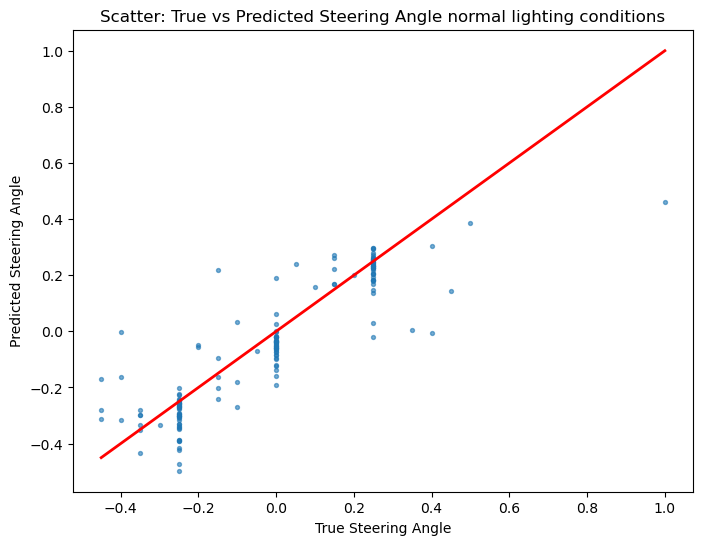

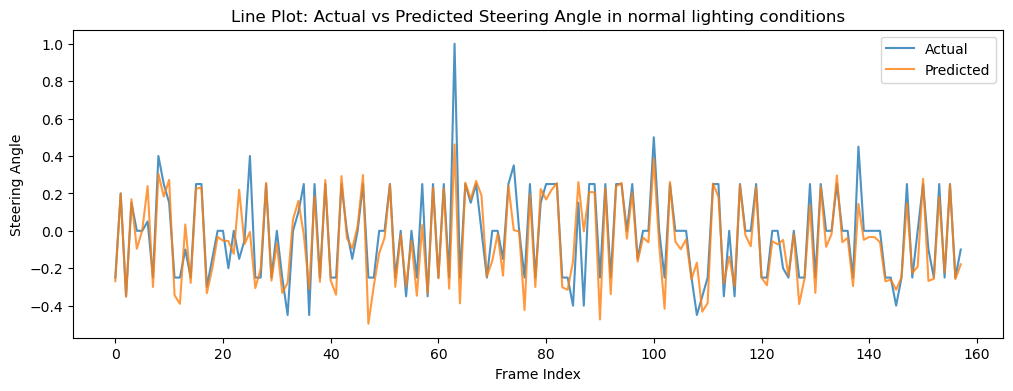

The total amount of turns sampled in this dataset is: 158
The amount of lane departures caused by this model is: 36
Turn error rate: 22.78%


In [11]:
#Creating a second test split to show that the model is not overfitted to the original train-test split
trainDf, valDf = train_test_split(df, test_size=0.2, random_state=923, shuffle=True)

# Testing the model
# Making predictions

#Testing dataset
xFullList = []
yFullList = [] # Start with an empty list
correction = 0.25

for i in range(len(valDf)):
    # Get the current row data
    row = valDf.iloc[i]
    choice = random.choice(['center', 'left', 'right'])
    xFullList.append(row[choice])
    # Calculate corrected angle
    angle = row['steeringAngle']
    if choice == 'left':
        angle += correction
    elif choice == 'right':
        angle -= correction
        
    yFullList.append(angle)
# Convert both to numpy array
xFull = np.array(xFullList)
yFull = np.array(yFullList)

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2,shuffle=False)

yPred = []
for path in xValReal:
    img = loadImage(path)
    prediction = ControlledAnglePredictor.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)

# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("Scatter: True vs Predicted Steering Angle normal lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("Line Plot: Actual vs Predicted Steering Angle in normal lighting conditions")
plt.legend()
plt.show()

dispTurnError(yValReal,yPred)

In [13]:
# we will now train a temporary model on the ENTIRE dataset with varying brightnesses using brightenImage(from 1.1 to 2.0)
# this will be our sesitivity analysis for brightness. We will pick the best performing model and brightness value to be our "bright"
# representative
# for the purpose of readability, we will encapsulate the bright code in a function that will be repeated for each brightness value,
# and we will only display the MSE, R2 and number of lane departures

def BrightnessTesting(value):
    # Splitting the dataset and using Nvidia's model architecture
    # Split dataset(keeping the random_state same)
    trainBrightDf, valBrightDf = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
    
    # Model
    BrightAnglePredictor = Sequential([
        Input(shape=(66,200,3)),
        Conv2D(24, (5,5), strides=(2,2), activation='relu'),
        Conv2D(36, (5,5), strides=(2,2), activation='relu'),
        Conv2D(48, (5,5), strides=(2,2), activation='relu'),
        Conv2D(64, (3,3), activation='relu'),
        Conv2D(64, (3,3), activation='relu'),
        Flatten(),
        Dense(100, activation='relu'),
        Dense(50, activation='relu'),
        Dense(10, activation='relu'),
        Dense(1)
    ])
    
    BrightAnglePredictor.compile(
        optimizer='adam', 
        loss='mean_squared_error',
        metrics=['accuracy']
    )
    
    # BrightAnglePredictor.summary()
    
    # Training
    batchSize = 32
    stepsPerEpoch = len(trainDf) // batchSize
    validationSteps = len(valDf) // batchSize
    
    earlyStop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    
    history = BrightAnglePredictor.fit(
        generatorForBrightness(trainBrightDf, value, batchSize),
        steps_per_epoch=stepsPerEpoch,
        validation_data=generatorForBrightness(valBrightDf, value, batchSize),
        validation_steps=validationSteps,
        epochs=30,
        callbacks=[earlyStop]
    )
    
    BrightAnglePredictor.save("BrightAnglePredictor.keras")

    # Testing the model
    # Making predictions
    
    #Testing dataset
    xFullList = []
    yFullList = [] # Start with an empty list
    correction = 0.25
    
    for i in range(len(valBrightDf)):
        # Get the current row data
        row = valBrightDf.iloc[i]
        choice = random.choice(['center', 'left', 'right'])
        if random.random() > 0.5:
            xFullList.append(row[choice])
        else:
            # DO NOT store image, just store path
            xFullList.append(row[choice])
        # Calculate corrected angle
        angle = row['steeringAngle']
        if choice == 'left':
            angle += correction
        elif choice == 'right':
            angle -= correction
            
        yFullList.append(angle)
    # Convert both to numpy array
    xFull = np.array(xFullList)
    yFull = np.array(yFullList)
    
    unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2, shuffle=False)
    
    yPred = []
    for path in xValReal:
        img = loadImage(path)
        prediction = BrightAnglePredictor.predict(np.expand_dims(img, 0), verbose=0)[0][0]
        yPred.append(prediction)
    
    yPred = np.array(yPred)
    
    # Metrics/visualisation
    
    print("MSE:", mean_squared_error(yValReal, yPred))
    print("R² :", r2_score(yValReal, yPred))
    
    dispTurnError(yValReal,yPred)

# Brightness coefficient (between 1.1 and 1.9)
value = 1
for i in range(9):
    value +=0.1
    BrightnessTesting(value)
    print(value)

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.2714 - loss: 0.0603 - val_accuracy: 0.2513 - val_loss: 0.0589
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.2707 - loss: 0.0580 - val_accuracy: 0.2552 - val_loss: 0.0619
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.2860 - loss: 0.0597 - val_accuracy: 0.2799 - val_loss: 0.0618
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.2640 - loss: 0.0602 - val_accuracy: 0.2786 - val_loss: 0.0584
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.2746 - loss: 0.0610 - val_accuracy: 0.2721 - val_loss: 0.0604
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.2723 - loss: 0.0602 - val_accuracy: 0.2552 - val_loss: 0.0593
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2723 - loss: 0.0617 - val_accuracy: 0.2747 - val_loss: 0.0558
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.2879 - loss: 0.0580 - val_accuracy: 0.2826 - v

In [14]:
# we will now train a temporary model on the ENTIRE dataset with varying brightnesses using brightenImage(from 0.9 to 0.1)
# this will be our sesitivity analysis for brightness. We will pick the best performing model and brightness value to be our "Dark"
# representative
# for the purpose of readability, we will encapsulate the bright code in a function that will be repeated for each brightness value,
# and we will only display the MSE, R2 and number of lane departures

def DarknessTesting(value):
    # Splitting the dataset and using Nvidia's model architecture
    # Split dataset(keeping the random_state same)
    trainDarkDf, valDarkDf = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
    
    # Model
    DarkAnglePredictor = Sequential([
        Input(shape=(66,200,3)),
        Conv2D(24, (5,5), strides=(2,2), activation='relu'),
        Conv2D(36, (5,5), strides=(2,2), activation='relu'),
        Conv2D(48, (5,5), strides=(2,2), activation='relu'),
        Conv2D(64, (3,3), activation='relu'),
        Conv2D(64, (3,3), activation='relu'),
        Flatten(),
        Dense(100, activation='relu'),
        Dense(50, activation='relu'),
        Dense(10, activation='relu'),
        Dense(1)
    ])
    
    DarkAnglePredictor.compile(
        optimizer='adam', 
        loss='mean_squared_error',
        metrics=['accuracy']
    )
    
    # DarkAnglePredictor.summary()
    
    # Training
    batchSize = 32
    stepsPerEpoch = len(trainDf) // batchSize
    validationSteps = len(valDf) // batchSize
    
    earlyStop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    
    history = DarkAnglePredictor.fit(
        generatorForBrightness(trainDarkDf, value, batchSize),
        steps_per_epoch=stepsPerEpoch,
        validation_data=generatorForBrightness(valDarkDf, value, batchSize),
        validation_steps=validationSteps,
        epochs=30,
        callbacks=[earlyStop]
    )
    
    DarkAnglePredictor.save("DarkAnglePredictor.keras")

    # Testing the model
    # Making predictions
    
    #Testing dataset
    xFullList = []
    yFullList = [] # Start with an empty list
    correction = 0.25
    
    for i in range(len(valDarkDf)):
        # Get the current row data
        row = valDarkDf.iloc[i]
        choice = random.choice(['center', 'left', 'right'])
        if random.random() > 0.5:
            xFullList.append(row[choice])
        else:
            # DO NOT store image, just store path
            xFullList.append(row[choice])
        # Calculate corrected angle
        angle = row['steeringAngle']
        if choice == 'left':
            angle += correction
        elif choice == 'right':
            angle -= correction
            
        yFullList.append(angle)
    # Convert both to numpy array
    xFull = np.array(xFullList)
    yFull = np.array(yFullList)
    
    unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2, shuffle=False)
    
    yPred = []
    for path in xValReal:
        img = loadImage(path)
        prediction = DarkAnglePredictor.predict(np.expand_dims(img, 0), verbose=0)[0][0]
        yPred.append(prediction)
    
    yPred = np.array(yPred)
    
    # Metrics/visualisation
    
    print("MSE:", mean_squared_error(yValReal, yPred))
    print("R² :", r2_score(yValReal, yPred))
    
    dispTurnError(yValReal,yPred)

# Darkness coefficient (between 0.9 and 0.1)
value = 1
for i in range(9):
    value -=0.1
    DarknessTesting(value)
    print(value)

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.2561 - loss: 0.0475 - val_accuracy: 0.2773 - val_loss: 0.0229
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.2653 - loss: 0.0189 - val_accuracy: 0.2695 - val_loss: 0.0153
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.2707 - loss: 0.0162 - val_accuracy: 0.2812 - val_loss: 0.0141
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.2698 - loss: 0.0156 - val_accuracy: 0.2695 - val_loss: 0.0152
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.2586 - loss: 0.0150 - val_accuracy: 0.2513 - val_loss: 0.0153
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2707 - loss: 0.0154 - val_accuracy: 0.2904 - val_loss: 0.0159
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.2561 - loss: 0.0141 - val_accuracy: 0.2773 - val_loss: 0.0151
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.2634 - loss: 0.0144 - val_accuracy: 0.2917 - v

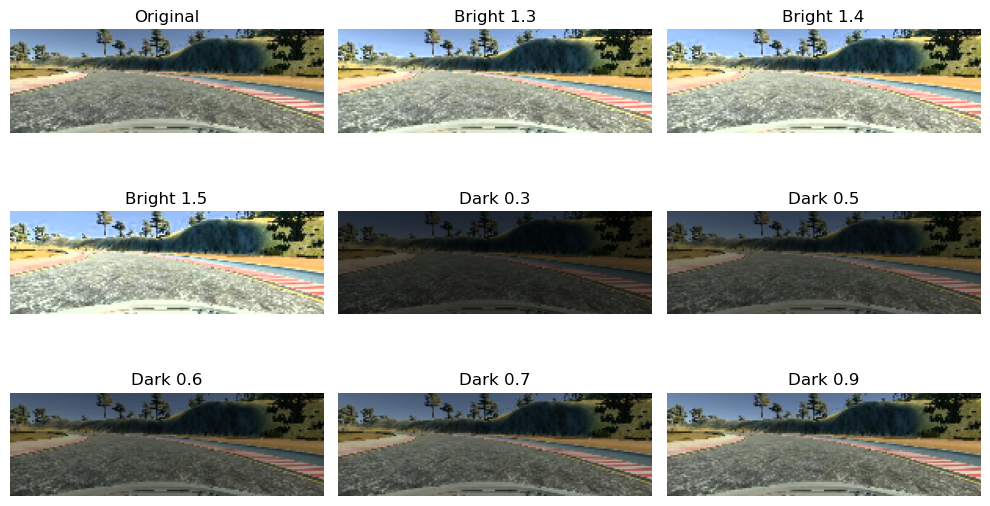

In [15]:
img = loadImage(df['center'][3])

plt.figure(figsize=(10,6))

plt.subplot(3,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(brightenImage(img, 1.3))
plt.title("Bright 1.3")
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(brightenImage(img, 1.4))
plt.title("Bright 1.4")
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(brightenImage(img, 1.5))
plt.title("Bright 1.5")
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(darkenImage(img, 0.3))
plt.title("Dark 0.3")
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(darkenImage(img, 0.5))
plt.title("Dark 0.5")
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(darkenImage(img, 0.6))
plt.title("Dark 0.6")
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(darkenImage(img, 0.7))
plt.title("Dark 0.7")
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(darkenImage(img, 0.9))
plt.title("Dark 0.9")
plt.axis('off')

plt.tight_layout()
#The highest performing bright value was close between 1.3, 1.4 and 1.5 so I decided to take 1.5 as 1.4 and 1.3 create a relatively unnoticeable differences.
#The highest performing dark value was a close match between 0.3,0.5,0.6,0.7 and 0.9 so I decided to take 0.5 as 0.9 has a very slight difference from normal 
#while 0.7, 0.6, and 0.5 have similar darknesses. I chose 0.5 as it has the same difference from 1 as 1.5 (bright value)

In [17]:
# we will now train a new model on bright, dark and normal images

# Splitting the dataset and using Nvidia's model architecture
# Split dataset
trainDf, valDf = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

# Model
AnglePredictorFullPotential = Sequential([
    Input(shape=(66,200,3)),
    Conv2D(24, (5,5), strides=(2,2), activation='relu'),
    Conv2D(36, (5,5), strides=(2,2), activation='relu'),
    Conv2D(48, (5,5), strides=(2,2), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1)
])
AnglePredictorFullPotential.compile(
    optimizer='adam', 
    loss='mean_squared_error',
    metrics=['accuracy']
)
AnglePredictorFullPotential.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_140 (Conv2D)             │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_141 (Conv2D)             │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_142 (Conv2D)             │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_143 (Conv2D)             │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_144 (Conv2D)             │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_28 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Training
batchSize = 32
stepsPerEpoch = len(trainDf) // batchSize
validationSteps = len(valDf) // batchSize

earlyStop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history = AnglePredictorFullPotential.fit(
    trainingGeneratorForBrightness(trainDf, batchSize),
    steps_per_epoch=stepsPerEpoch,
    validation_data=trainingGeneratorForBrightness(valDf, batchSize),
    validation_steps=validationSteps,
    epochs=30,
    callbacks=[earlyStop]
)

AnglePredictorFullPotential.save("AnglePredictorFullPotential.keras")

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.2592 - loss: 0.0500 - val_accuracy: 0.2578 - val_loss: 0.0281
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.2653 - loss: 0.0214 - val_accuracy: 0.2344 - val_loss: 0.0202
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.2688 - loss: 0.0182 - val_accuracy: 0.2760 - val_loss: 0.0200
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.2758 - loss: 0.0174 - val_accuracy: 0.2773 - val_loss: 0.0185
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2640 - loss: 0.0173 - val_accuracy: 0.2422 - val_loss: 0.0170
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.2924 - loss: 0.0161 - val_accuracy: 0.2852 - val_loss: 0.0160
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2803 - loss: 0.0155 - val_accuracy: 0.2708 - val_loss: 0.0157
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.2685 - loss: 0.0160 - val_accuracy: 0.2721 - v

MSE: 0.0067335064091743405
R² : 0.8816122253316993


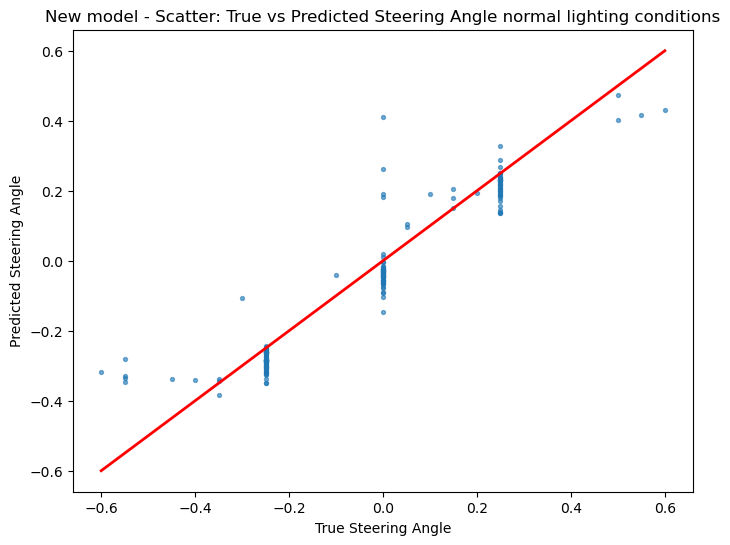

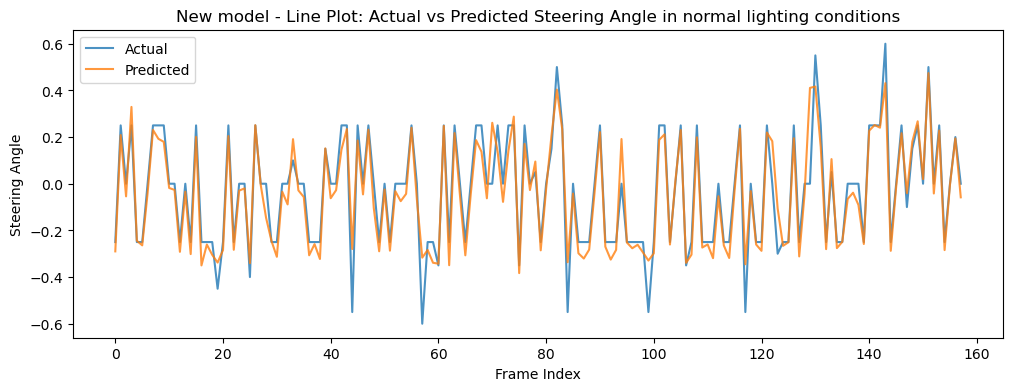

The total amount of turns sampled in this dataset is: 158
The amount of lane departures caused by this model is: 20
Turn error rate: 12.66%


In [19]:
# Testing the model
# Making predictions

#Testing dataset
xFullList = []
yFullList = [] # Start with an empty list
correction = 0.25

for i in range(len(valDf)):
    # Get the current row data
    row = valDf.iloc[i]
    choice = random.choice(['center', 'left', 'right'])
    xFullList.append(row[choice])
    # Calculate corrected angle
    angle = row['steeringAngle']
    if choice == 'left':
        angle += correction
    elif choice == 'right':
        angle -= correction
        
    yFullList.append(angle)
# Convert both to numpy array
xFull = np.array(xFullList)
yFull = np.array(yFullList)

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2, shuffle=False)

yPred = []
for path in xValReal:
    img = loadImage(path)
    prediction = AnglePredictorFullPotential.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)

# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("New model - Scatter: True vs Predicted Steering Angle normal lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("New model - Line Plot: Actual vs Predicted Steering Angle in normal lighting conditions")
plt.legend()
plt.show()

dispTurnError(yValReal,yPred)

MSE: 0.011877118094428181
R² : 0.7784984150603039


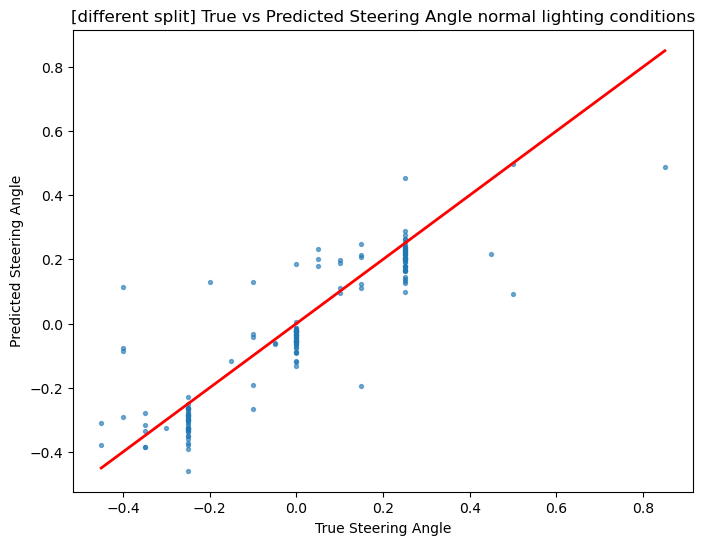

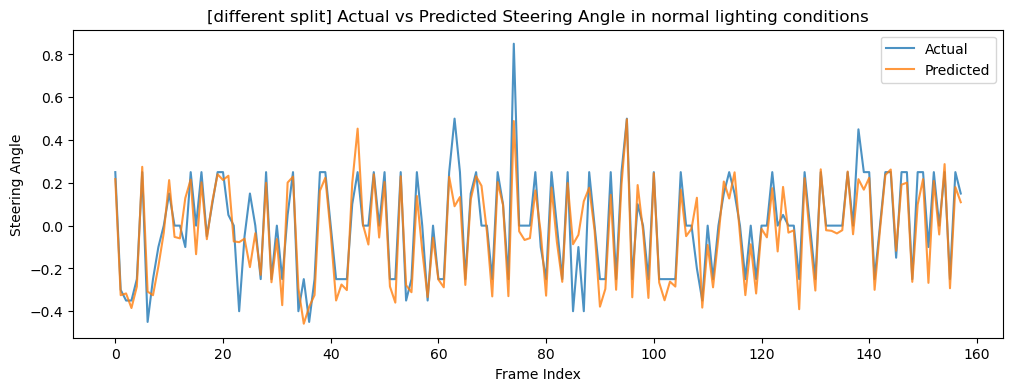

The total amount of turns sampled in this dataset is: 158
The amount of lane departures caused by this model is: 30
Turn error rate: 18.99%


In [20]:
#Creating a second test split to show that the model is not overfitted to the original train-test split
trainDf, valDf = train_test_split(df, test_size=0.2, random_state=923, shuffle=True)

# Testing the model
# Making predictions

#Testing dataset
xFullList = []
yFullList = [] # Start with an empty list
correction = 0.25

for i in range(len(valDf)):
    # Get the current row data
    row = valDf.iloc[i]
    choice = random.choice(['center', 'left', 'right'])
    xFullList.append(row[choice])
    # Calculate corrected angle
    angle = row['steeringAngle']
    if choice == 'left':
        angle += correction
    elif choice == 'right':
        angle -= correction
        
    yFullList.append(angle)
# Convert both to numpy array
xFull = np.array(xFullList)
yFull = np.array(yFullList)

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2,shuffle=False)

yPred = []
for path in xValReal:
    img = loadImage(path)
    prediction = AnglePredictorFullPotential.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)

# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("[different split] True vs Predicted Steering Angle normal lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("[different split] Actual vs Predicted Steering Angle in normal lighting conditions")
plt.legend()
plt.show()

dispTurnError(yValReal,yPred)

MSE: 0.007900627352083625
R² : 0.8339989379957312


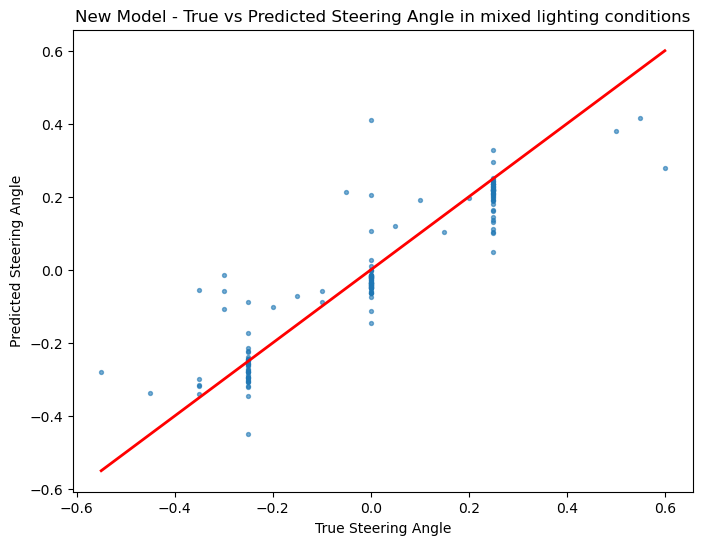

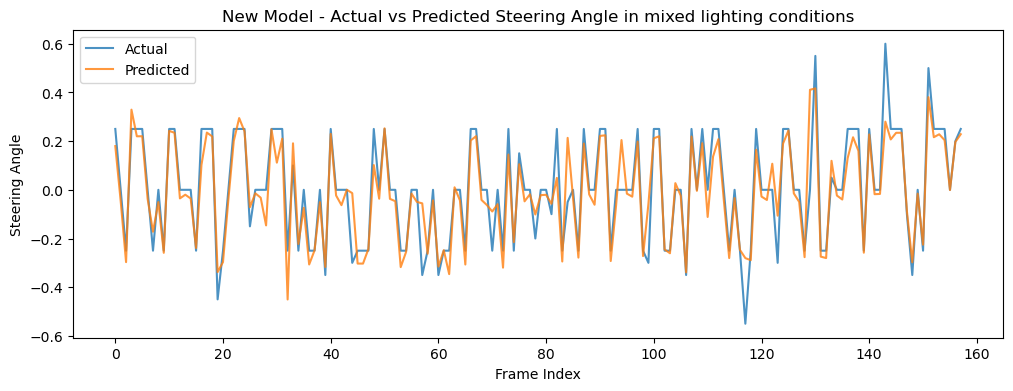

The total amount of turns sampled in this dataset is: 158
The amount of lane departures caused by this model is: 24
Turn error rate: 15.19%


In [21]:
#reverting to original split
trainDf, valDf = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)


# Testing the model
# Making predictions

#Testing dataset
xFullList = []
yFullList = [] # Start with an empty list
correction = 0.25

for i in range(len(valDf)):
    # Get the current row data
    row = valDf.iloc[i]
    choice = random.choice(['center', 'left', 'right'])
    xFullList.append(row[choice])
    # Calculate corrected angle
    angle = row['steeringAngle']
    if choice == 'left':
        angle += correction
    elif choice == 'right':
        angle -= correction
        
    yFullList.append(angle)
# Convert both to numpy array
xFull = np.array(xFullList)
yFull = np.array(yFullList)

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2,shuffle=False)

yPred = []
for path in xValReal:
    img = loadImage(path)
    # Random lighting condition
    choice = random.choice(['normal', 'bright', 'dark'])
    if choice == 'normal':
        # normal
        pass
    elif choice == "bright":
        # bright
        factor = 1.6
        img = brightenImage(img, factor=factor)
    else:
        # dark
        factor = 0.4
        img = darkenImage(img, factor=factor)
    prediction = AnglePredictorFullPotential.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)

# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("New Model - True vs Predicted Steering Angle in mixed lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("New Model - Actual vs Predicted Steering Angle in mixed lighting conditions")
plt.legend()
plt.show()

dispTurnError(yValReal,yPred)

MSE: 0.007936489774422947
R² : 0.8332454281883356


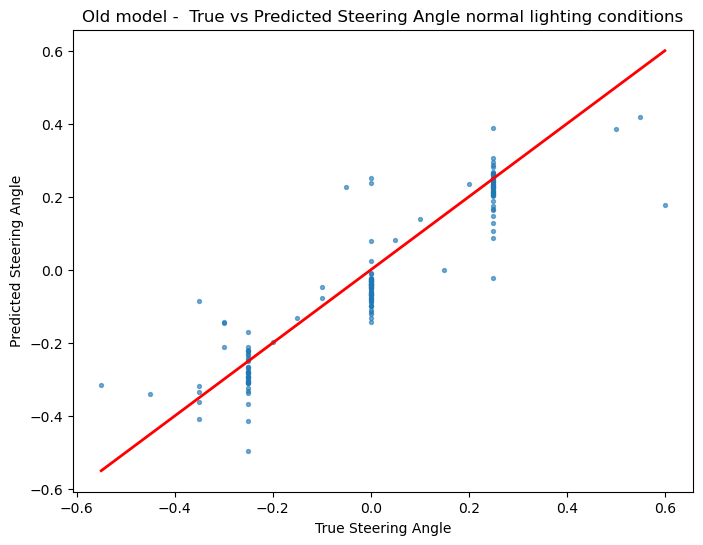

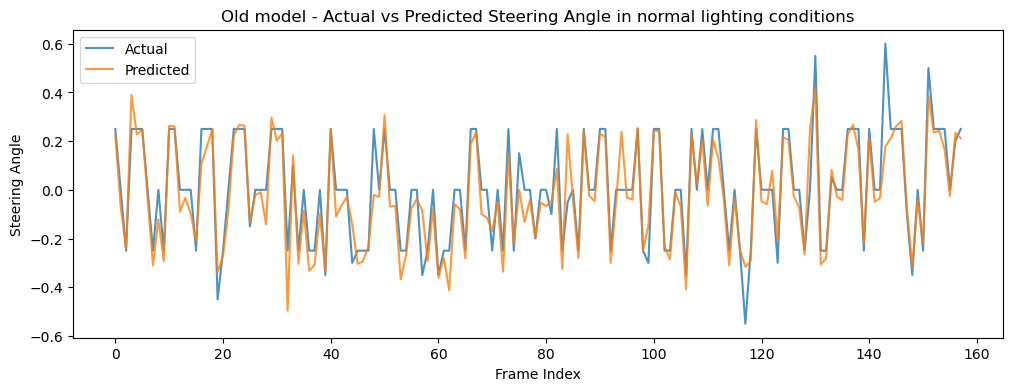

The total amount of turns sampled in this dataset is: 158
The amount of lane departures caused by this model is: 26
Turn error rate: 16.46%


In [22]:
# Testing the old model in the mixed dataset (NOT THE OVERFIT SET)
# Making predictions

#same dataset as the above

yPred = []
for path in xValReal:
    img = loadImage(path)
    prediction = ControlledAnglePredictor.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)


# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("Old model -  True vs Predicted Steering Angle normal lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("Old model - Actual vs Predicted Steering Angle in normal lighting conditions")
plt.legend()
plt.show()

dispTurnError(yValReal,yPred)